# Relación entre tiempo, categoría y valor de las ventas

En este notebook analizo cómo cambia el valor de las ventas de diferentes categorías a través del tiempo. Utilizo un mapa de calor para comparar el importe total de las órdenes entre categorías y meses e identificar patrones o diferencias en las ventas.

In [1]:
from pathlib import Path
import pandas as pd

rutas_dataset = [
    Path('../data/Amazon_Sales.csv'),
    Path('data/Amazon_Sales.csv')
]
ruta_dataset = next((ruta for ruta in rutas_dataset if ruta.exists()), None)
if ruta_dataset is None:
    raise FileNotFoundError('No se encontró data/Amazon_Sales.csv')

df = pd.read_csv(ruta_dataset)
columnas_analisis = ['Date', 'Category', 'Amount']
print('Dimensiones del dataset:', df.shape)
print('Tipos originales:')
print(df[columnas_analisis].dtypes)
print('\nValores faltantes:')
print(df[columnas_analisis].isna().sum())
print('\nEjemplos de Date:')
print(df['Date'].head(10).to_list())
print('\nCategorías:', df['Category'].dropna().unique().tolist())
print('\nEjemplos de Amount:')
print(df['Amount'].head(10).to_list())

Dimensiones del dataset: (128975, 22)
Tipos originales:
Date         object
Category     object
Amount      float64
dtype: object

Valores faltantes:
Date        0
Category    0
Amount      0
dtype: int64

Ejemplos de Date:
['22/04/30', '22/04/30', '22/04/30', '22/04/30', '22/04/30', '22/04/30', '22/04/30', '22/04/30', '22/04/30', '22/04/30']

Categorías: ['Set', 'kurta', 'Western Dress', 'Top', 'Ethnic Dress', 'Bottom', 'Saree', 'Blouse', 'Dupatta']

Ejemplos de Amount:
[647.62, 406.0, 329.0, 753.33, 574.0, 824.0, 653.0, 399.0, 0.0, 363.0]


Filas originales: 128975
Filas válidas para el análisis: 128975
Filas excluidas por fecha inválida/faltante: 0
Filas excluidas por categoría faltante/vacía: 0
Filas excluidas por Amount faltante/no numérico: 0
Filas con Amount infinito: 0
Amount cero conservado: 10138

Distribución de Amount para revisar escala y extremos:


,Amount
count,128975.00
mean,609.36
std,313.35
min,0.00
50%,583.00
90%,1033.00
95%,1166.00
99%,1442.00
max,5584.00



Matriz de importe total por mes y categoría (INR):


Category,Blouse,Bottom,Dupatta,Ethnic Dress,Saree,Set,Top,Western Dress,kurta
Mes,,,,,,,,,
2022-03,280.00,0.00,0.0,1099.00,0.00,53884.00,4511.00,7653.28,34256.57
2022-04,195583.21,63308.45,0.0,250666.65,55655.24,15506675.56,1821893.22,2927780.51,8017145.48
2022-05,159794.68,50866.57,0.0,293092.34,41536.62,12643698.35,1995607.16,4381304.41,6660576.62
2022-06,102750.29,36492.96,915.0,246359.67,26741.90,10999866.12,1525780.92,3899334.49,6587568.03



Categoría con mayor importe en cada mes:


...


Importe total por categoría (orden descendente):


,Importe total
Category,
Set,39204124.03
kurta,21299546.70
Western Dress,11216072.69
Top,5347792.30
Ethnic Dress,791217.66
Blouse,458408.18
Bottom,150667.98
Saree,123933.76
Dupatta,915.00



Importe total por mes (orden cronológico):


,Importe total
Mes,
2022-03,101683.85
2022-04,28838708.32
2022-05,26226476.75
2022-06,23425809.38



Mes con mayor importe total: 2022-04 (28,838,708.32 INR)
Combinación mes-categoría con mayor importe: 2022-04 / Set (15,506,675.56 INR)
Combinación mes-categoría con menor importe: 2022-03 / Bottom (0.00 INR)


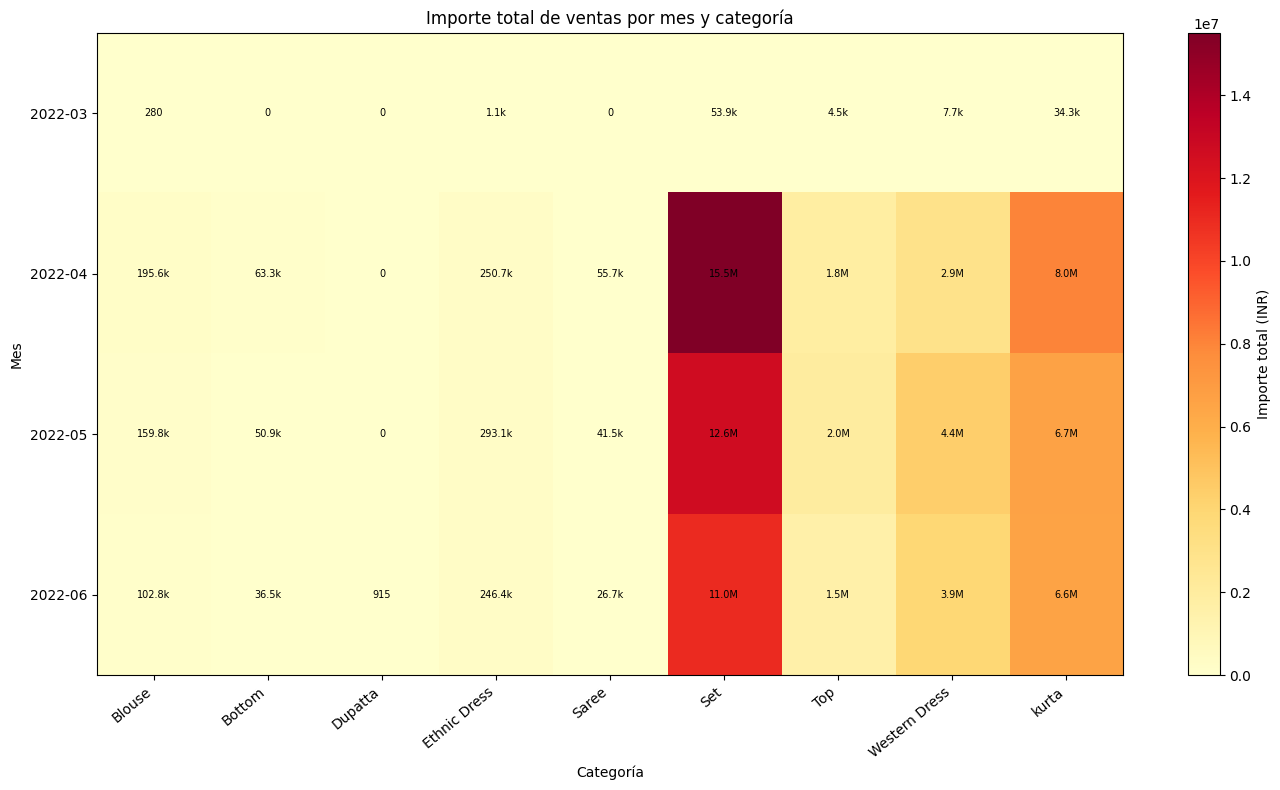


Uso comercial: comparar estos patrones por mes puede ayudar a anticipar la demanda por categoría, ajustar inventario y evaluar en qué periodos conviene probar promociones. El heatmap describe importes observados; por sí solo no demuestra que una temporada o categoría cause cambios en las ventas.


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Convertir cada campo y conservar solo filas válidas para esta agregación.
ventas = df[['Date', 'Category', 'Amount']].copy()
ventas['Date'] = pd.to_datetime(ventas['Date'], format='%y/%m/%d', errors='coerce')
ventas['Category'] = ventas['Category'].astype('string').str.strip()
ventas.loc[ventas['Category'].eq(''), 'Category'] = pd.NA
ventas['Amount'] = pd.to_numeric(ventas['Amount'], errors='coerce')

mascara_importe_finito = np.isfinite(ventas['Amount'])
mascara_valida = (
    ventas['Date'].notna()
    & ventas['Category'].notna()
    & ventas['Amount'].notna()
    & mascara_importe_finito
)
ventas_limpias = ventas.loc[mascara_valida].copy()
ventas_limpias['Mes'] = ventas_limpias['Date'].dt.to_period('M')

print('Filas originales:', len(ventas))
print('Filas válidas para el análisis:', len(ventas_limpias))
print('Filas excluidas por fecha inválida/faltante:', int(ventas['Date'].isna().sum()))
print('Filas excluidas por categoría faltante/vacía:', int(ventas['Category'].isna().sum()))
print('Filas excluidas por Amount faltante/no numérico:', int(ventas['Amount'].isna().sum()))
print('Filas con Amount infinito:', int((~mascara_importe_finito & ventas['Amount'].notna()).sum()))
print('Amount cero conservado:', int(ventas_limpias['Amount'].eq(0).sum()))
print('\nDistribución de Amount para revisar escala y extremos:')
display(ventas_limpias['Amount'].describe(percentiles=[0.5, 0.9, 0.95, 0.99]).to_frame().round(2))

# Sumar el importe por mes y categoría; el índice Period conserva el orden cronológico.
totales_mes_categoria = (
    ventas_limpias.groupby(['Mes', 'Category'], observed=True)['Amount']
    .sum()
    .rename('Importe total')
)
matriz_ventas = totales_mes_categoria.unstack('Category', fill_value=0).sort_index()
matriz_ventas = matriz_ventas.reindex(sorted(matriz_ventas.columns), axis=1)
matriz_ventas.index = matriz_ventas.index.astype(str)

print('\nMatriz de importe total por mes y categoría (INR):')
display(matriz_ventas.round(2))

# Resúmenes para identificar picos mensuales, categorías líderes y combinaciones extremas.
categoria_lider_mes = matriz_ventas.idxmax(axis=1).to_frame('Categoría con mayor importe')
categoria_lider_mes['Importe total'] = matriz_ventas.max(axis=1)
totales_por_mes = matriz_ventas.sum(axis=1).sort_values(ascending=False).rename('Importe total')
totales_por_categoria = matriz_ventas.sum(axis=0).sort_values(ascending=False).rename('Importe total')
combinacion_maxima = matriz_ventas.stack().idxmax()
combinacion_minima = matriz_ventas.stack().idxmin()

print('\nCategoría con mayor importe en cada mes:')
display(categoria_lider_mes.round(2))
print('\nImporte total por categoría (orden descendente):')
display(totales_por_categoria.to_frame().round(2))
print('\nImporte total por mes (orden cronológico):')
display(matriz_ventas.sum(axis=1).rename('Importe total').to_frame().round(2))
print(
    f"\nMes con mayor importe total: {totales_por_mes.index[0]} "
    f"({totales_por_mes.iloc[0]:,.2f} INR)"
)
print(
    f"Combinación mes-categoría con mayor importe: {combinacion_maxima[0]} / "
    f"{combinacion_maxima[1]} ({matriz_ventas.loc[combinacion_maxima]:,.2f} INR)"
)
print(
    f"Combinación mes-categoría con menor importe: {combinacion_minima[0]} / "
    f"{combinacion_minima[1]} ({matriz_ventas.loc[combinacion_minima]:,.2f} INR)"
)

# Seleccionar las cinco categorías con mayor importe acumulado en todo el periodo.
top_5_categorias = totales_por_categoria.head(5)
matriz_top_5 = matriz_ventas[top_5_categorias.index]
print('\nTop 5 categorías por importe total (INR), seleccionadas para el heatmap:')
display(top_5_categorias.to_frame().round(2))

fig, ax = plt.subplots(figsize=(11, 7))
imagen = ax.imshow(matriz_top_5.to_numpy(), aspect='auto', cmap='YlOrRd')
fig.colorbar(imagen, ax=ax, label='Importe total (INR)')
ax.set_xticks(np.arange(len(matriz_top_5.columns)))
ax.set_xticklabels(matriz_top_5.columns, rotation=40, ha='right')
ax.set_yticks(np.arange(len(matriz_top_5.index)))
ax.set_yticklabels(matriz_top_5.index)
ax.set_xlabel('Categoría')
ax.set_ylabel('Mes')
ax.set_title('Importe total por mes: 5 categorías principales')

# Usar formato exacto en importes menores de mil para que no parezcan ceros.
for fila in range(matriz_top_5.shape[0]):
    for columna in range(matriz_top_5.shape[1]):
        valor = matriz_top_5.iat[fila, columna]
        if valor == 0:
            etiqueta = '0'
        elif valor < 1_000:
            etiqueta = f'{valor:,.0f}'
        elif valor < 1_000_000:
            etiqueta = f'{valor / 1_000:.1f}k'
        else:
            etiqueta = f'{valor / 1_000_000:.1f}M'
        ax.text(columna, fila, etiqueta, ha='center', va='center', fontsize=8, color='black')

fig.tight_layout()
plt.show()

print(
    '\nUso comercial: comparar estos patrones por mes puede ayudar a anticipar la demanda '
    'por categoría, ajustar inventario y evaluar en qué periodos conviene probar promociones. '
    'El heatmap describe importes observados; por sí solo no demuestra que una temporada o '
    'categoría cause cambios en las ventas.'
)